In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [3]:
# Load the ER wait-time dataset
DATA_PATH = Path('../../data/er_wait_time.csv')
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
print(df.head())


Dataset shape: (5000, 19)
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon           Low   

   Nur

Target column: Total Wait Time (min)
Feature columns: ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Patient Outcome', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Patient Satisfaction']


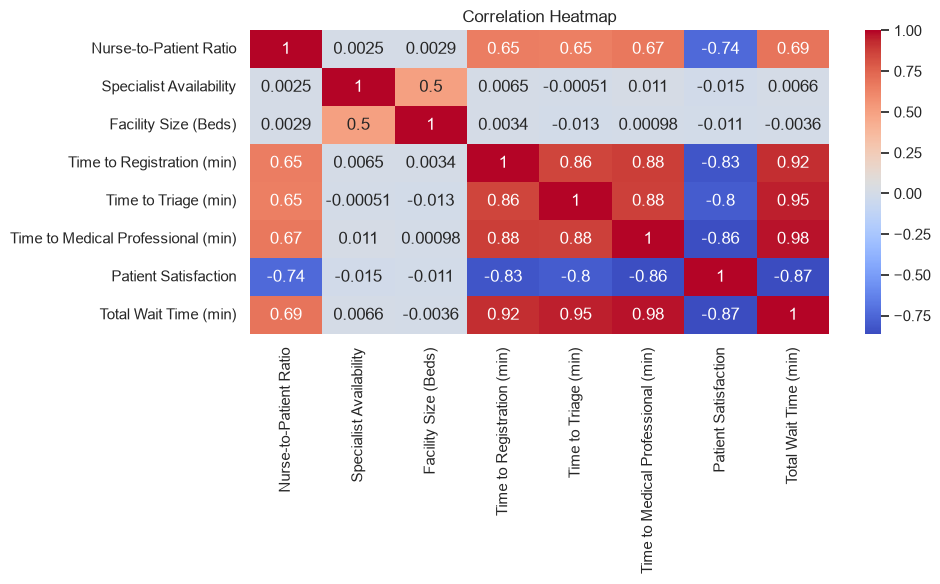

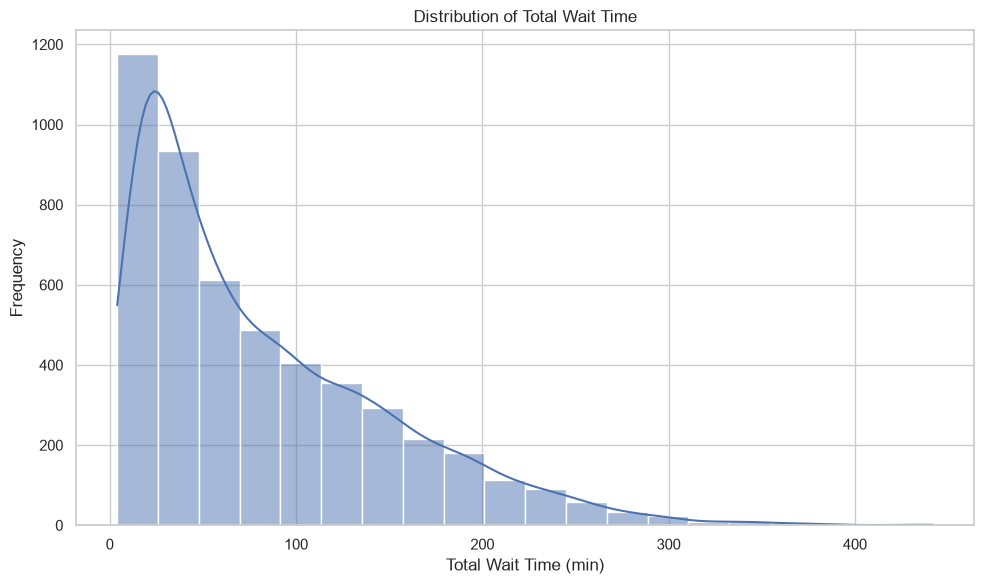

In [4]:
# Explore the data and choose the target and feature columns
TARGET = 'Total Wait Time (min)'
CATEGORICAL_FEATURES = ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Patient Outcome']
NUMERIC_FEATURES = [
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)',
    'Patient Satisfaction'
]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[FEATURES]
y = df[TARGET]

print('Target column:', TARGET)
print('Feature columns:', FEATURES)

# Visualisations for the assignment rubric
plt.figure(figsize=(10, 6))
sns.heatmap(df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET], kde=True, bins=20)
plt.title('Distribution of Total Wait Time')
plt.xlabel('Total Wait Time (min)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


                            mae          rmse        r2
Linear Regression  5.942269e-14  7.211606e-14  1.000000
SGD Regressor      1.116799e-01  1.402687e-01  0.999996
Random Forest      1.443844e+00  2.981136e+00  0.998090
Decision Tree      3.777313e+00  5.871959e+00  0.992588
Best model saved to: ..\..\summative\linear_regression\models\best_er_wait_model.joblib
Sample prediction for one test row: 265.0


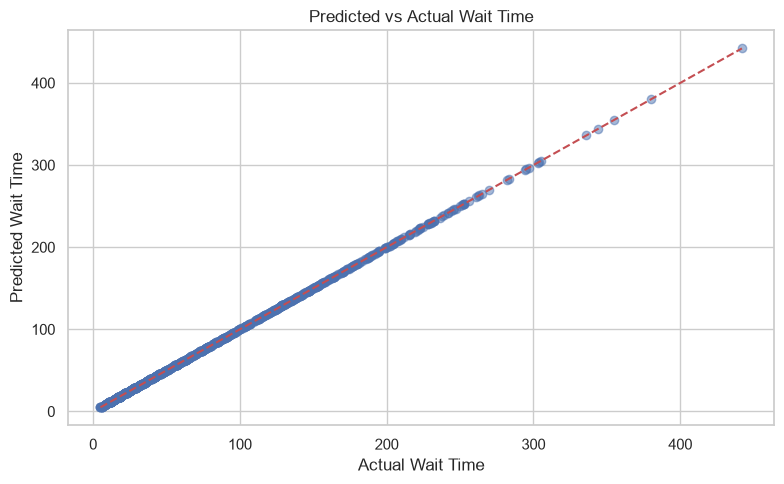

In [6]:
# Split data and build multiple regression models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('numeric', StandardScaler(), NUMERIC_FEATURES)
    ]
)

models = {
    'Linear Regression': Pipeline([
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]),
    'SGD Regressor': Pipeline([
        ('preprocess', preprocessor),
        ('model', SGDRegressor(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, max_depth=10, min_samples_leaf=2))
    ]),
    'Decision Tree': Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8))
    ])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'mae': mean_absolute_error(y_test, preds),
        'rmse': mean_squared_error(y_test, preds) ** 0.5,
        'r2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T.sort_values('mae')
print(results_df)

best_model_name = results_df.index[0]
best_model = models[best_model_name]

# Save the best-performing model in the Task 1 workspace
MODEL_PATH = Path('../../summative/linear_regression/models/best_er_wait_model.joblib')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print('Best model saved to:', MODEL_PATH)

# Make a single prediction for one row in the test set
sample_row = X_test.iloc[[0]]
sample_prediction = best_model.predict(sample_row)[0]
print('Sample prediction for one test row:', round(sample_prediction, 2))

# Plot the best-fit relationship for the final linear model
if best_model_name == 'Linear Regression':
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, best_model.predict(X_test), alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title('Predicted vs Actual Wait Time')
    plt.xlabel('Actual Wait Time')
    plt.ylabel('Predicted Wait Time')
    plt.tight_layout()
    plt.show()
